# Téléchargement et exploration des données

In [2]:
# Imports
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from nilearn import datasets
import plotly.express as px
import warnings #
warnings.filterwarnings('ignore', category=DeprecationWarning)
import os #

In [3]:
# Download data
data_dir = './nilearn_data' # ajout de l'endroit pour télécharger data, plus facile à répliquer ensuite
data = datasets.fetch_adhd(n_subjects=40, data_dir = data_dir) # prend tout le dataset disponible contrairement à étude original

[fetch_adhd] Dataset found in nilearn_data/adhd


In [4]:
# Type de données dans notre data set
data.keys()

dict_keys(['func', 'confounds', 'phenotypic', 'description', 't_r'])

In [5]:
# Transformation de phenotypes en taableau
pheno = pd.DataFrame(data.phenotypic)

In [6]:
# Tous les types de données phénotype possible
pheno.columns 

Index(['Unnamed: 0', 'Subject', 'Rest.Scan', 'MeanFD',
       'NumFD_greater_than_0.20', 'rootMeanSquareFD', 'FDquartile.top1.4thFD.',
       'PercentFD_greater_than_0.20', 'MeanDVARS', 'MeanFD_Jenkinson', 'site',
       'sibling_id', 'data_set', 'age', 'sex', 'handedness', 'full_2_iq',
       'full_4_iq', 'viq', 'piq', 'iq_measure', 'tdc', 'adhd',
       'adhd_inattentive', 'adhd_combined', 'adhd_subthreshold',
       'diagnosis_using_cdis', 'notes', 'sess_1_anat_2', 'oppositional',
       'cog_inatt', 'hyperac', 'anxious_shy', 'perfectionism',
       'social_problems', 'psychosomatic', 'conn_adhd', 'restless_impulsive',
       'emot_lability', 'conn_gi_tot', 'dsm_iv_inatt', 'dsm_iv_h_i',
       'dsm_iv_tot', 'study', 'sess_1_rest_1', 'sess_1_rest_1_eyes',
       'sess_1_rest_2', 'sess_1_rest_2_eyes', 'sess_1_rest_3',
       'sess_1_rest_3_eyes', 'sess_1_rest_4', 'sess_1_rest_4_eyes',
       'sess_1_rest_5', 'sess_1_rest_5_eyes', 'sess_1_rest_6',
       'sess_1_rest_6_eyes', 'sess_1_a

In [7]:
# Vérifier combien de participants ont des données phéno
len(pheno) 

30

Il est anormale que notre dataframe pheno a seulement 30 participants (donc la fonction data.phenotypic ne fonctionne pas correctement). On doit ainsi aller manuellement chercher les données phénotypes pour avoir tous les 40 participants

In [8]:
pheno_all = pd.read_csv('nilearn_data/adhd/ADHD200_40subs_motion_parameters_and_phenotypics.csv')
print(len(pheno_all)) # Vérification qu'il a bien 40 participants maintenant

40


On va regarder les distributions pour les 30 participants et les 40 participants pour visualiser les différences

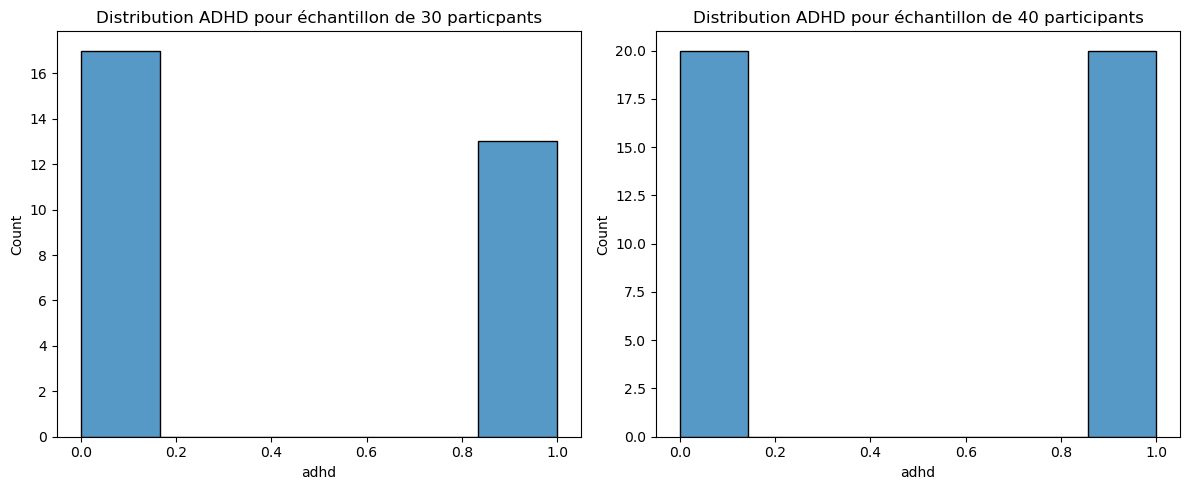

In [9]:
# Regarder la distribution des diagnostics de TDAH
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# échantillon de 30 personnes
sns.histplot(pheno['adhd'], ax=ax1)
ax1.set_title("Distribution ADHD pour échantillon de 30 particpants")

# échantillon de 40 personnes
sns.histplot(pheno_all['adhd'], ax=ax2)
ax2.set_title("Distribution ADHD pour échantillon de 40 participants")

plt.tight_layout()
plt.show()

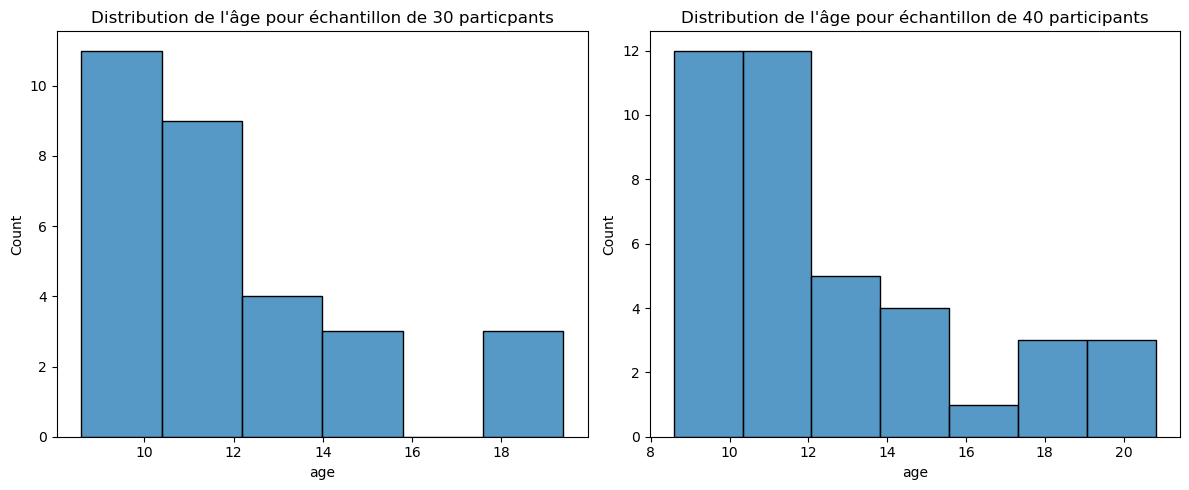

In [10]:
# Regarder la distribution d'âge
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# échantillon de 30 personnes
sns.histplot(pheno['age'], ax=ax1)
ax1.set_title("Distribution de l'âge pour échantillon de 30 particpants")

# échantillon de 40 personnes
sns.histplot(pheno_all['age'], ax=ax2)  
ax2.set_title("Distribution de l'âge pour échantillon de 40 participants")

plt.tight_layout()
plt.show()

In [11]:
# Identifier les sujets manquants de l'échantillon de 30 participants
manquants = set(pheno_all['Subject']) - set(pheno['Subject'])
print(manquants)

{23008, 27011, 23012, 27018, 10128, 10064, 27034, 21019, 10042, 27037}


In [12]:
# Comparaison avec les sujets du projet original
pheno_original = pd.read_csv('projet_original/pheno_table.csv')

diff_pheno40 = set(pheno_all['Subject']) - set(pheno_original['Subject'])
diff_pheno30 = set(pheno['Subject']) - set(pheno_original['Subject'])

print(diff_pheno40)
print(diff_pheno30)

{4134561, 7774305, 4275075, 9750701, 8697774, 9744150, 4046678, 4164316, 6115230, 8409791}
{4134561, 7774305, 4275075, 9750701, 8697774, 9744150, 4046678, 4164316, 6115230, 8409791}


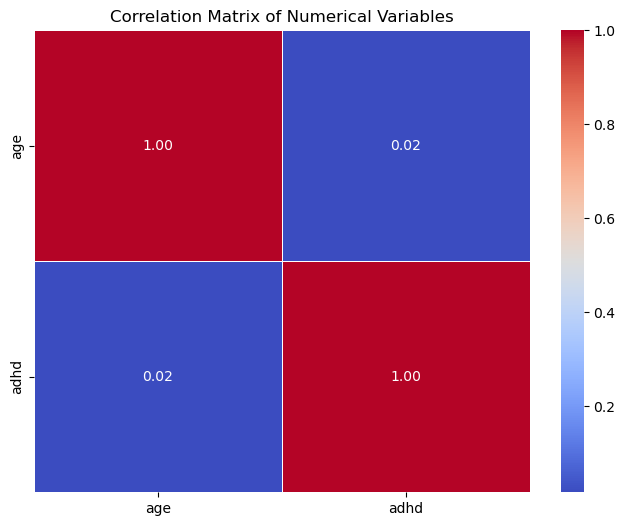

In [13]:
# Matrice de corrélation de l'âge et du diagnostic TDAH 
numerical_cols = ['age', 'adhd']
df_numeric = pheno_all[numerical_cols]

# Compute the correlation matrix
correlation_matrix = df_numeric.corr()

# Visualize the correlation matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

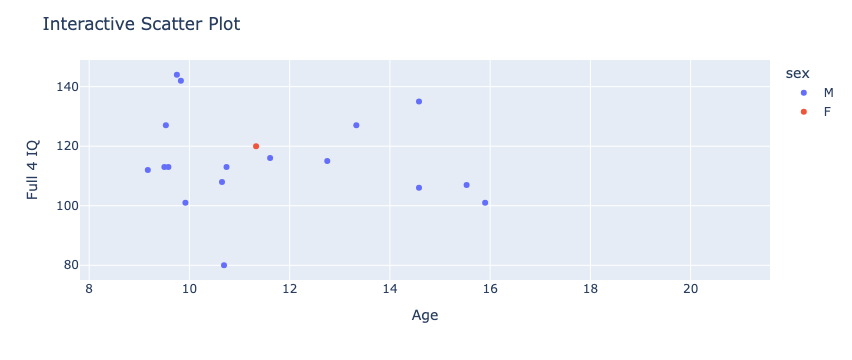

In [14]:
# Reproduction du scatter plot
fig = px.scatter(pheno_all, x='age', y='full_4_iq', color='sex', hover_data=['adhd', 'cog_inatt', 'hyperac', 'anxious_shy', 'perfectionism',
       'social_problems','conn_adhd', 'restless_impulsive',])

fig.update_layout(
    title="Interactive Scatter Plot",
    xaxis_title="Age",
    yaxis_title="Full 4 IQ"
)

fig.show()

In [15]:
# Vérification de pourquoi graphique différent que projet initial
print(pheno_all[['age', 'full_4_iq']].isna().sum())

age           0
full_4_iq    22
dtype: int64



Contrairement au projet original, l'utilisation de son code ne montre pas les participants qui n'ont pas de valeur au full_4_iq (notre graphique présente 22 participants de moins). Je préfère cette visualisation que l'original qui met un peu arbitrairement les données manquantes au milieu du graphique, induisant un peu en erreur l'interprétation de la figure


# Préparation des données

In [16]:
from nilearn.input_data import NiftiLabelsMasker
from nilearn.connectome import ConnectivityMeasure
from nilearn import plotting
from nilearn import image
from nilearn.plotting import plot_connectome
import nibabel as nib

/var/folders/rw/8w59v3ld03q_jn0m9p0qxr1r0000gn/T/ipykernel_54239/1858551965.py:1: FutureWarning: The import path 'nilearn.input_data' is deprecated in version 0.9. Importing from 'nilearn.input_data' will be possible at least until release 0.13.0. Please import from 'nilearn.maskers' instead.
  from nilearn.input_data import NiftiLabelsMasker


## Extraction des features

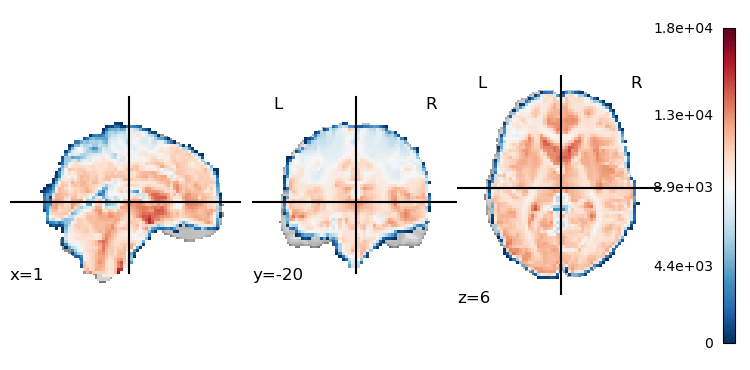

In [17]:
# Image moyenne pour séries temporelles d'un sujet
fmri_filenames = data.func[0]
averaged_Img = image.mean_img(fmri_filenames)
plotting.plot_stat_map(averaged_Img) 

Il semble avoir eu un changement dans la valeur par défaut pour le cmap. Le projet original avait cmap = 'cold_hot' sans la mentionner directement dans le code tandis que la valeur par défaut dans la présente version de nilearn est 'RdBu_r'

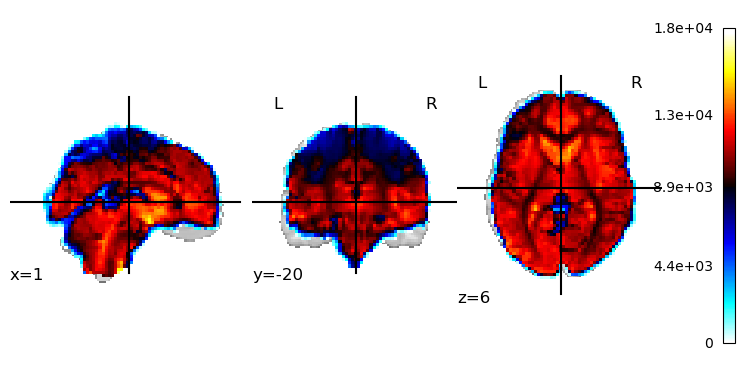

In [18]:
# Pour avoir la même figure que le projet original
plotting.plot_stat_map(averaged_Img, cmap='cold_hot') 

In [19]:
#Importer l'atlas
parcellations = datasets.fetch_atlas_basc_multiscale_2015(version='sym', resolution=64) 
atlas_filename = parcellations.maps 

[fetch_atlas_basc_multiscale_2015] Dataset found in /Users/anhthinguyen/nilearn_data/basc_multiscale_2015


MODIFICATION: Avec le présente version de nilearn, on doit maintenant préciser quelle résolution on veut lorsqu'on fetch l'atlas, semble qu'ancienne version retournait toutes les versions en même temps. Les keys ont également changer, donc on doit faire parcellations.maps pour avoir le file_name de l'atlas

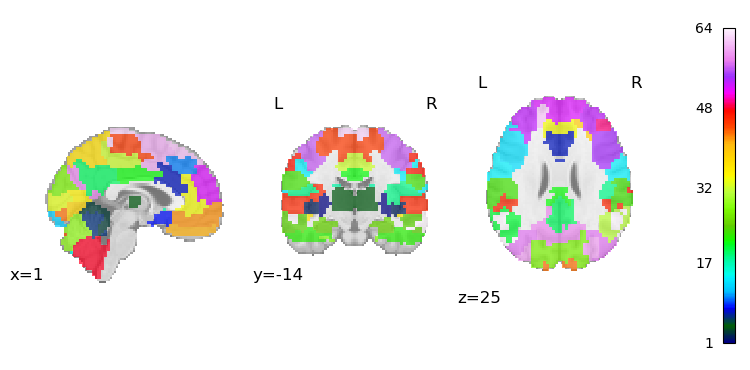

In [20]:
#Plot atlas
plotting.plot_roi(atlas_filename, draw_cross = False)

In [21]:
# Création du masque
mask = NiftiLabelsMasker(labels_img=atlas_filename, 
                           standardize='zscore_sample', #standardize = True est deprecated et donne pleins de warnings
                           memory='nilearn_cache', 
                           verbose=0)

# Initialisation de la mesure de corrélation
correlation_measure = ConnectivityMeasure(kind='correlation', standardize='zscore_sample')

MODIFICATION: 
Il y a de l'incohérence dans le projet original. Il initialise une mesure de corrélation qui enlève la diagonale et vectorize = True donc garde seulement le triangle inférieur + flatten puis retourne un array de 1D. Par contre, dans la boucle pour faire la matrice de corrélation pour tous les sujets, on reinitialise la mesure de corrélation sans enlever la diagonale et avec vectorize = False ce qui retourne un array de 2D. L'array de 2D est utile pour les visualisations (comme fait dans le projet original), mais utiliser ce type d'array donne de l'information qui est redondante pour les modèles de classifications.

Étant donné que la tâche 1 est de reproduire le notebook originale, je vais garder la version qui n'enlève pas la diagonale et vectorize=False. L'autre version sera utilisé dans la tâche 2

In [22]:
# Matrice de corrélation pour tous les sujets
all_features= []

for i, sub in enumerate(data.func):
    # Extraction des séries temporelles
    time_series = mask.fit_transform(sub, confounds=data.confounds[i])
    
    # Création de la matrice pour le sujet
    correlation_matrix = correlation_measure.fit_transform([time_series])[0]
    
    # Append features and file name to the list
    all_features.append(correlation_matrix)

In [23]:
# Flatten les matrices
flattened_features = [arr.flatten() for arr in all_features]

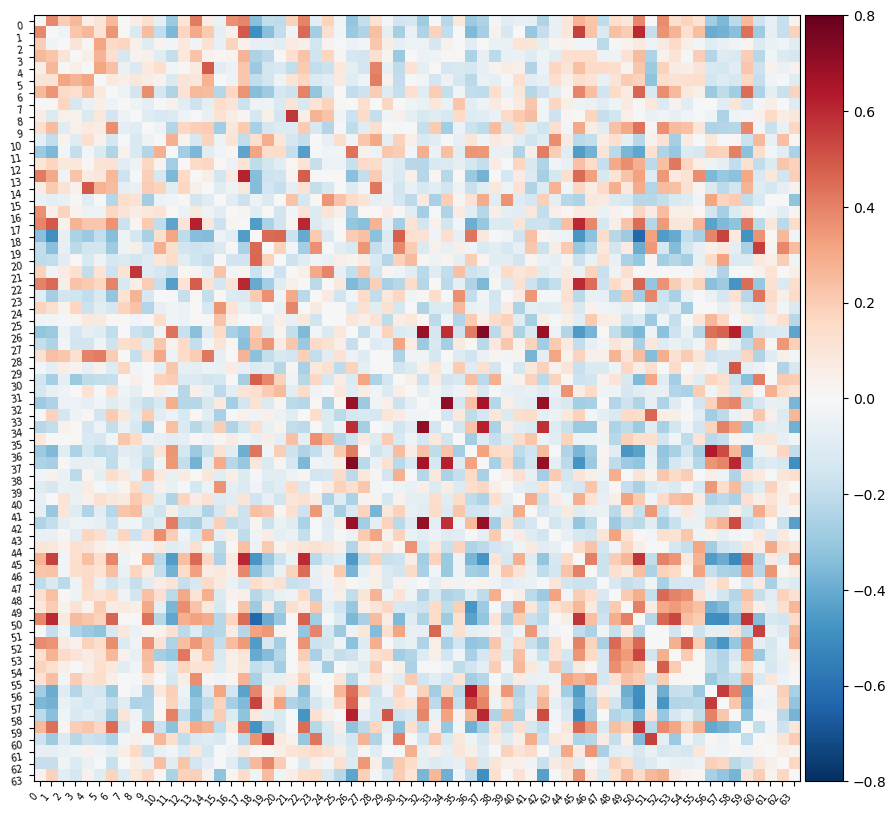

In [24]:
# Visualiser matrice de corrélation pour 1 sujet
correlation_matrix = all_features[0]
np.fill_diagonal(correlation_matrix, 0)

plotting.plot_matrix(correlation_matrix, figure=(10, 8),
                     labels=range(correlation_matrix.shape[0]),
                     vmax=0.8, vmin=-0.8, reorder=False)

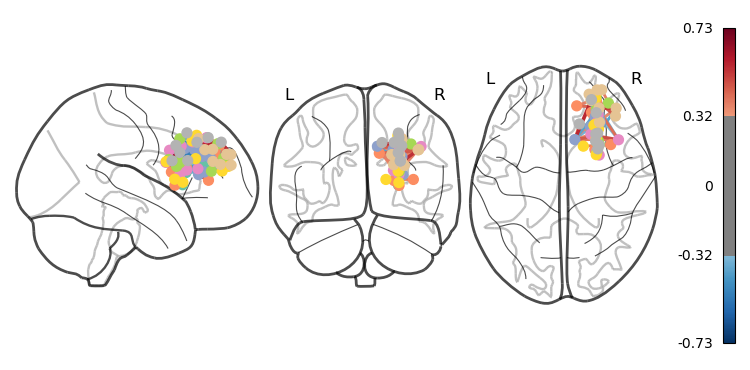

In [25]:
# Load the atlas image for the desired scale
atlas_img = nib.load(atlas_filename)

# Extract the data from the atlas image
atlas_data = atlas_img.get_fdata()

# Assuming the atlas data provides labels for each region
# You can use these labels to extract coordinates if available
# For example, if the atlas data is a 3D volume where each region is represented by a unique label,
# you can extract the coordinates of each label using numpy's `where` function:
label_coordinates = []
unique_labels = np.unique(atlas_data)
for label in unique_labels:
    if label != 0:  # Exclude background label if present
        label_coords = np.where(atlas_data == label)
        # Calculate the centroid or any other representative coordinate for the label if needed
        centroid = np.mean(label_coords, axis=1)
        label_coordinates.append(centroid)

# Now `label_coordinates` contains the coordinates of each region in the atlas

# We threshold to keep only the 10% of edges with the highest value
# because the graph is very dense
plot_connectome(correlation_matrix, label_coordinates,
                edge_threshold="90%", colorbar=True)

## Labeling des données

In [26]:
#Ajouter les features au dataframe des phénotypes
feature_series = pd.Series(flattened_features, name='features')
data_task1 = pd.concat([pheno_all, feature_series], axis=1)

In [27]:
# Sauvegarder le dataframe final qu'on va utiliser pour la classification de la tâche 1
path = './donnees_tache1.csv' #même nom que le projet original pour cohérence
data_task1.to_csv(path, index=False)

Text(0, 0.5, 'subjects')

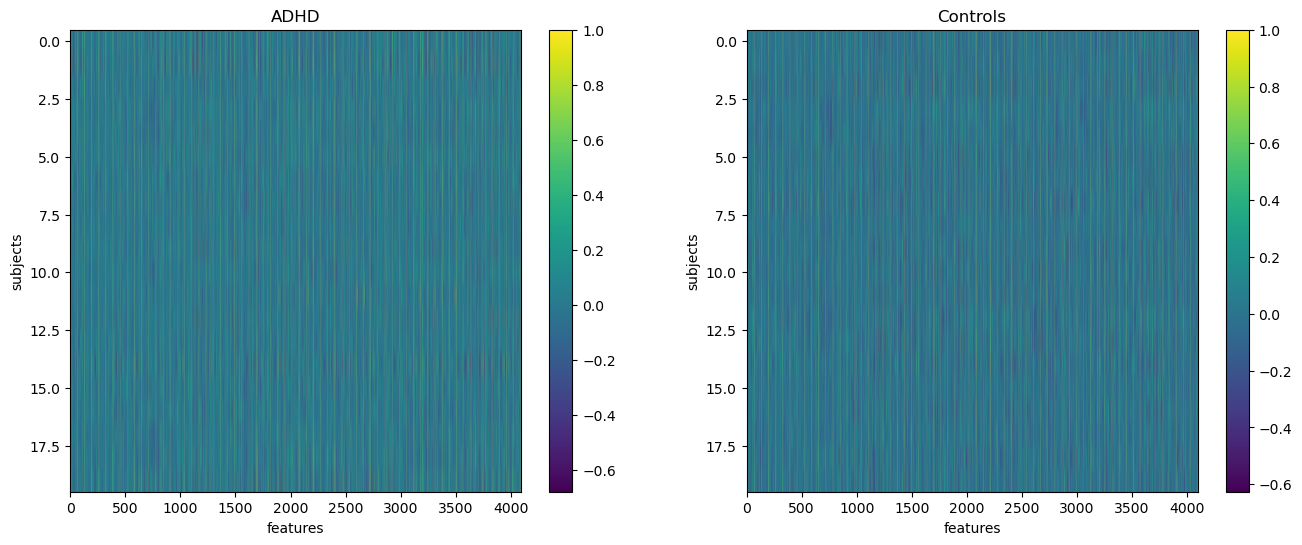

In [28]:
#Plot correlation matrix for 'adhd' and 'control' subjects 
from matplotlib.pyplot import figure

adhd_features = list(data_task1.loc[data_task1['adhd']==1]['features'])
control_features = list(data_task1.loc[data_task1['adhd']==0]['features'])

figure(figsize=(16,6))

plt.subplot(1, 2, 1)
plt.imshow(adhd_features, aspect='auto')
plt.colorbar()
plt.title('ADHD')
plt.xlabel('features')
plt.ylabel('subjects')


plt.subplot(1, 2, 2)
plt.imshow(control_features, aspect='auto')
plt.colorbar()
plt.title('Controls')
plt.xlabel('features')
plt.ylabel('subjects')

# Classificateurs

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import xgboost as xgb 

In [30]:
# Extract features and target variable
X = np.array(data_task1['features'].tolist())  # Convert features to numpy array
y = data_task1['adhd']

In [31]:
# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, shuffle=True, stratify=y, random_state=123)

In [32]:
# Initialize classifiers
classifiers = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "XGBoost": xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss')
}

In [33]:
# Calculate accuracy, F1 score and confusion matirx for each classifier 
confusion_matrices = []
results_task1 = {}
for clf_name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_val)
    accuracy = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)

    conf_matrix = confusion_matrix(y_val, y_pred)

    confusion_matrices.append((clf_name, conf_matrix))

    results_task1[clf_name] = {'Accuracy': accuracy, 'F1 Score': f1}
    print(f"{clf_name}: Accuracy={accuracy}, F1 Score={f1}")

KNN: Accuracy=0.75, F1 Score=0.6666666666666666
Logistic Regression: Accuracy=0.25, F1 Score=0.25
Decision Tree: Accuracy=0.375, F1 Score=0.4444444444444444
Random Forest: Accuracy=0.375, F1 Score=0.4444444444444444
SVM: Accuracy=0.625, F1 Score=0.7272727272727273
XGBoost: Accuracy=0.5, F1 Score=0.5


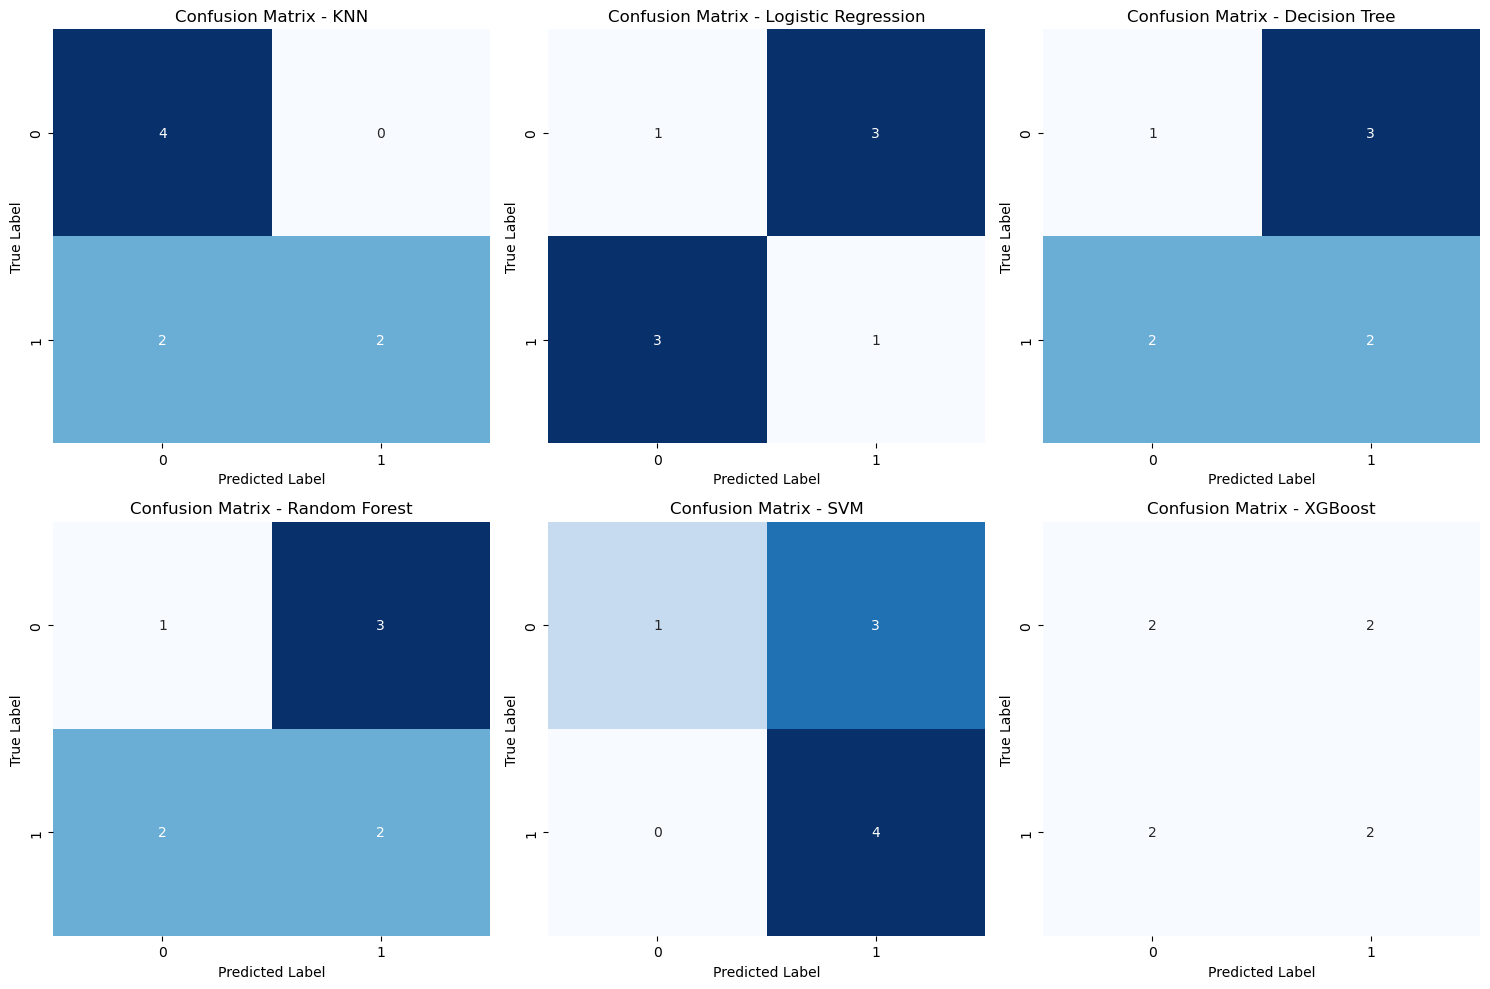

In [35]:
# Create a grid layout for confusion matrices
num_classifiers = len(classifiers)
num_rows = int(np.ceil(num_classifiers / 3))  # Adjust number of columns as needed
fig, axes = plt.subplots(num_rows, 3, figsize=(15, num_rows * 5))

# Plot and save confusion matrices in the grid
for i, (clf_name, conf_matrix) in enumerate(confusion_matrices):
    row = i // 3
    col = i % 3
    ax = axes[row, col]
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(f'Confusion Matrix - {clf_name}')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

# Adjust layout
plt.tight_layout()

# Save the entire grid as an image
os.makedirs('./figures/matrices_confusions', exist_ok=True)
plt.savefig('./figures/matrices_confusions/Modele1.png')
plt.show()


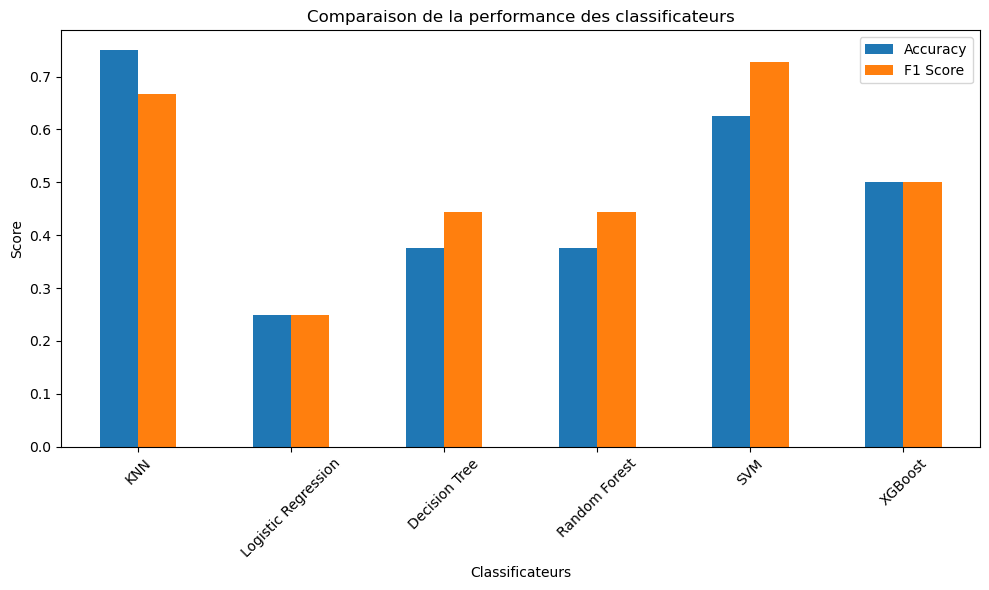

In [36]:
# Create a DataFrame from results
results_task1 = pd.DataFrame(results_task1).T

# Plot accuracy and F1 score for each model
results_task1.plot(kind='bar', figsize=(10, 6))
plt.title('Comparaison de la performance des classificateurs')
plt.xlabel('Classificateurs')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend(loc='upper right')
plt.tight_layout()

os.makedirs('./figures/performance', exist_ok=True)
plt.savefig('./figures/performance/Modele1.png')
plt.show()

# Modification de la pipeline d'entraînement et explication des modèles/mesures de performance (Tâche 2)

## Repréparation des données

In [37]:
# Initialisation de la mesure de corrélation
correlation_measure2 = ConnectivityMeasure(kind='correlation', vectorize=True,
                                         discard_diagonal=True, standardize='zscore_sample')

# Matrice de corrélation pour tous les sujets
all_features2= []

for i, sub in enumerate(data.func):
    # Extraction des séries temporelles
    time_series2 = mask.fit_transform(sub, confounds=data.confounds[i])
    
    # Création de la matrice pour le sujet
    correlation_matrix2 = correlation_measure2.fit_transform([time_series2])[0]
    
    # Append features and file name to the list
    all_features2.append(correlation_matrix2)

In [38]:
#Ajouter les features au dataframe des phénotypes
pheno_all = pd.read_csv('nilearn_data/adhd/ADHD200_40subs_motion_parameters_and_phenotypics.csv') #reload les données pour ne pas avoir la colonne de la tâche précédente
colonne_features = pd.Series(all_features2, name='features')
data_task2 = pd.concat([pheno_all, colonne_features], axis=1)

# Sauvegarder le dataframe final qu'on va utiliser pour la classification de la tâche 2
path = './donnees_tache2.csv' #même nom que le projet original pour cohérence
data_task2.to_csv(path, index=False)

Text(0, 0.5, 'subjects')

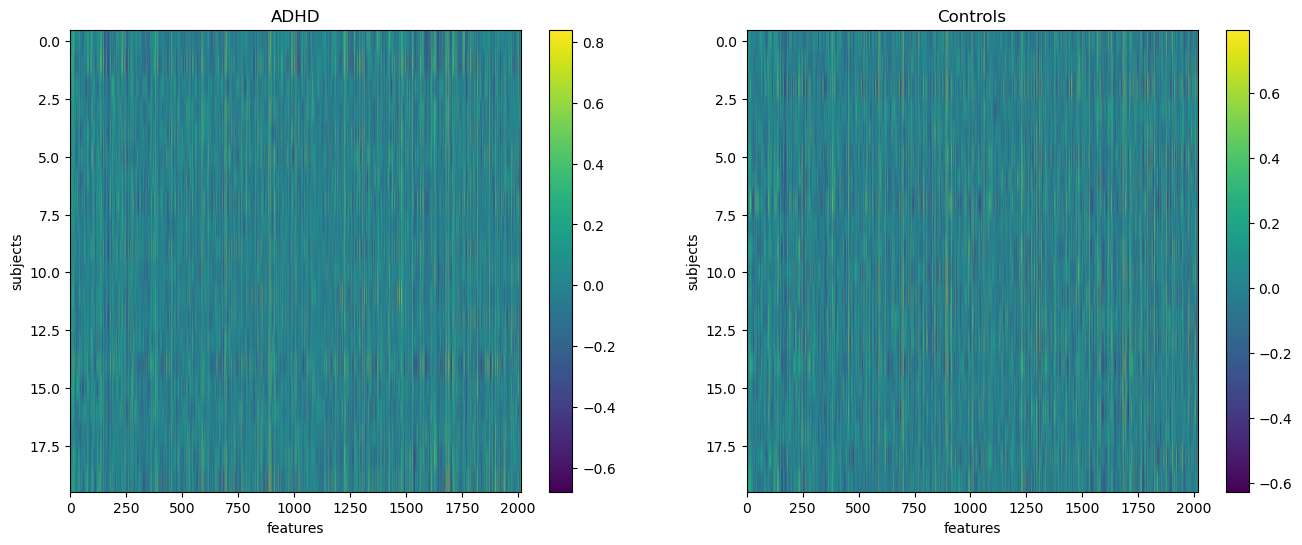

In [39]:
#Plot correlation matrix for 'adhd' and 'control' subjects 
adhd_features = list(data_task2.loc[data_task2['adhd']==1]['features'])
control_features = list(data_task2.loc[data_task2['adhd']==0]['features'])

figure(figsize=(16,6))

plt.subplot(1, 2, 1)
plt.imshow(adhd_features, aspect='auto')
plt.colorbar()
plt.title('ADHD')
plt.xlabel('features')
plt.ylabel('subjects')


plt.subplot(1, 2, 2)
plt.imshow(control_features, aspect='auto')
plt.colorbar()
plt.title('Controls')
plt.xlabel('features')
plt.ylabel('subjects')

## Nouveaux classificateurs

In [40]:
# Variables
X = np.array(data_task2['features'].tolist())  # Convert features to numpy array
y = data_task2['adhd']

### Effet de la modification de ConnectivityMeasure (on enlève la redondance des features)

In [41]:
# Séparation des données
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, shuffle=True, stratify=y, random_state=123)

# Calculer l'accuracy, F1 score et matrice de confusion pour chaque classificateur
confusion_matrices = []
results_connect = {}
for clf_name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_val)
    accuracy = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)

    conf_matrix = confusion_matrix(y_val, y_pred)

    confusion_matrices.append((clf_name, conf_matrix))

    results_connect[clf_name] = {'Accuracy': accuracy, 'F1 Score': f1}
    print(f"{clf_name}: Accuracy={accuracy}, F1 Score={f1}")

KNN: Accuracy=0.75, F1 Score=0.6666666666666666
Logistic Regression: Accuracy=0.25, F1 Score=0.25
Decision Tree: Accuracy=0.5, F1 Score=0.5
Random Forest: Accuracy=0.5, F1 Score=0.3333333333333333
SVM: Accuracy=0.625, F1 Score=0.7272727272727273
XGBoost: Accuracy=0.375, F1 Score=0.4444444444444444


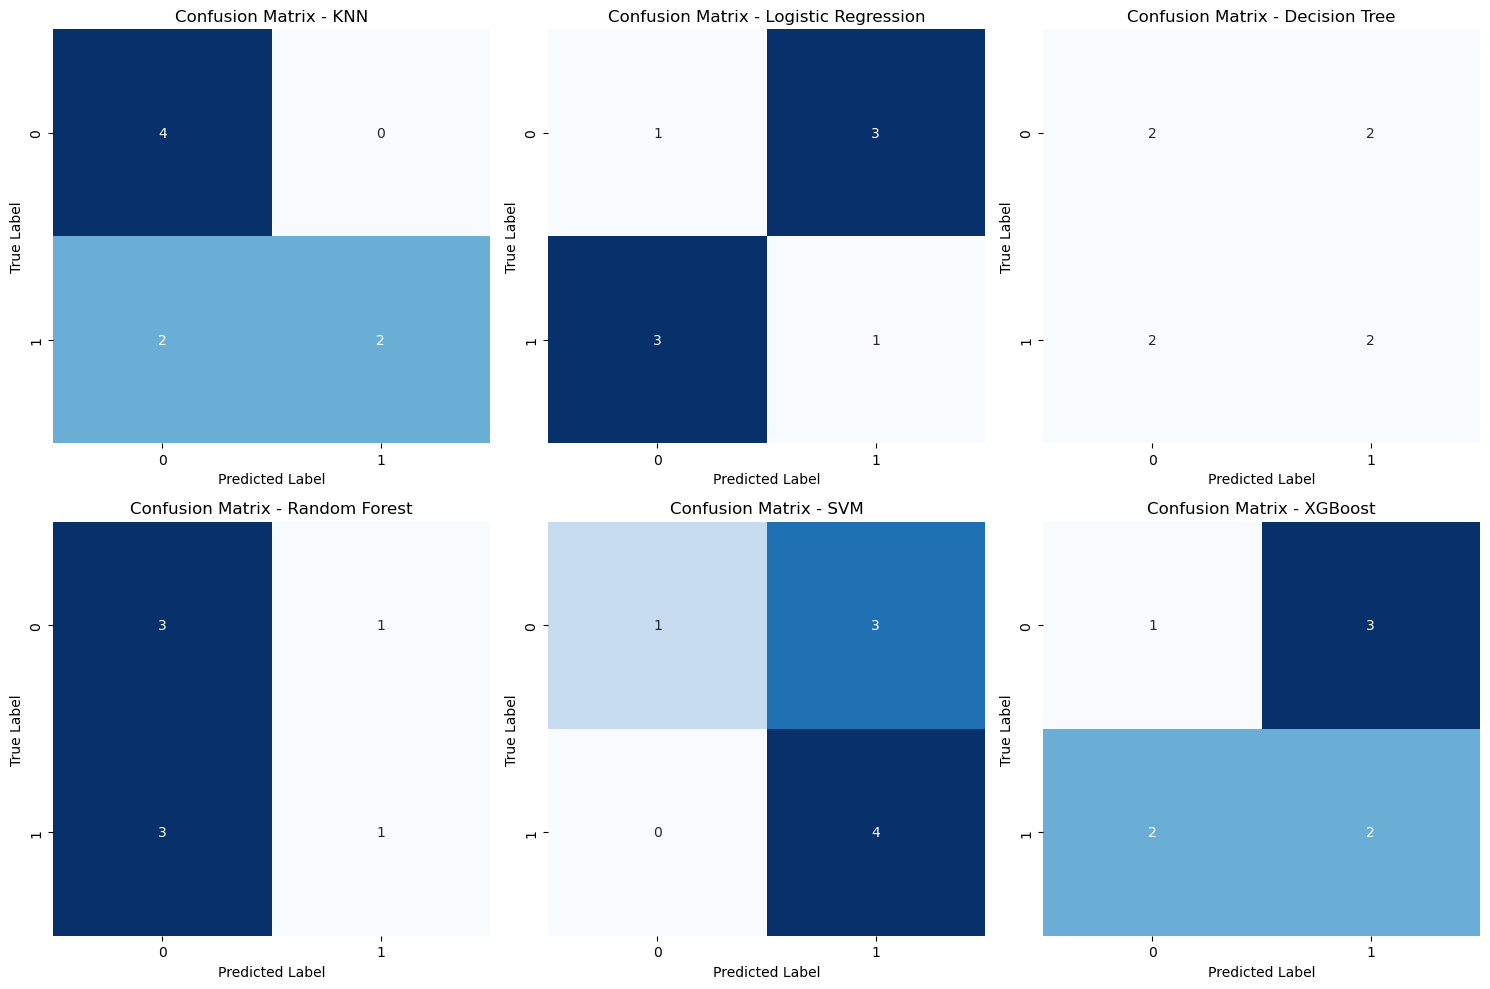

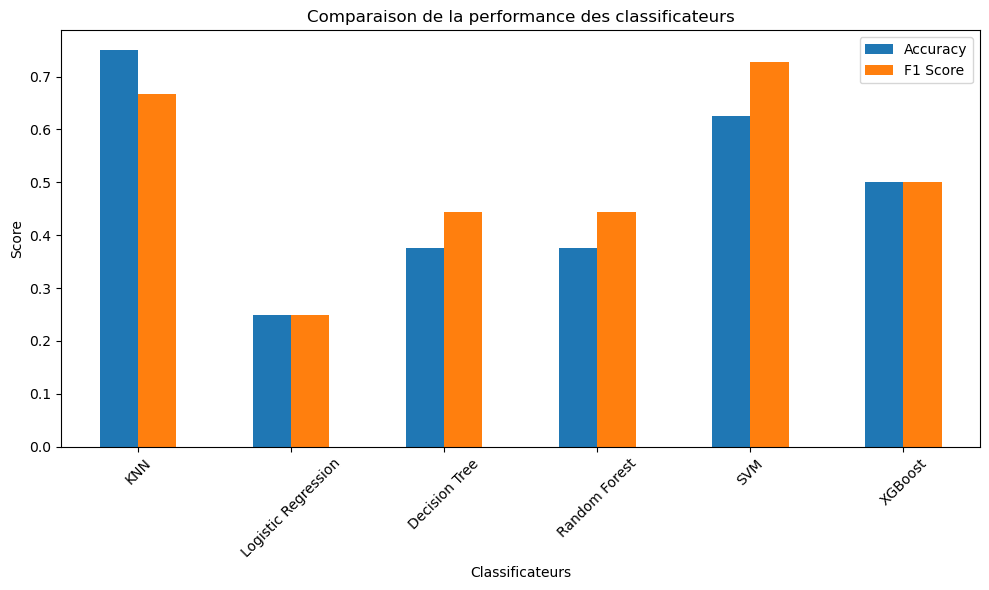

In [42]:
# Visualisations de la performance

# Matrices de confusion
num_classifiers = len(classifiers)
num_rows = int(np.ceil(num_classifiers / 3))
fig, axes = plt.subplots(num_rows, 3, figsize=(15, num_rows * 5))

for i, (clf_name, conf_matrix) in enumerate(confusion_matrices):
    row = i // 3
    col = i % 3
    ax = axes[row, col]
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(f'Confusion Matrix - {clf_name}')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.tight_layout()
os.makedirs('./figures/matrices_confusions', exist_ok=True)
plt.savefig('./figures/matrices_confusions/Modele2.png')

# Accuracy et F1 score
results_connect = pd.DataFrame(results_connect).T

# Plot accuracy and F1 score for each model
results_task1.plot(kind='bar', figsize=(10, 6))
plt.title('Comparaison de la performance des classificateurs')
plt.xlabel('Classificateurs')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend(loc='upper right')
plt.tight_layout()

os.makedirs('./figures/performance', exist_ok=True)
plt.savefig('./figures/performance/Modele2.png')

### Effet de la validation croisée

In [44]:
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import StratifiedKFold

cross_val = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

confusion_matrices = []
results_cv = {}
for clf_name, clf in classifiers.items():
    y_pred = cross_val_predict(clf, X, y, cv=cross_val)
    accuracy = accuracy_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    
    conf_matrix = confusion_matrix(y, y_pred)
    
    confusion_matrices.append((clf_name, conf_matrix))
    
    results_cv[clf_name] = {'Accuracy': accuracy, 'F1 Score': f1}
    print(f"{clf_name}: Accuracy={accuracy}, F1 Score={f1}")

KNN: Accuracy=0.425, F1 Score=0.30303030303030304
Logistic Regression: Accuracy=0.375, F1 Score=0.4186046511627907
Decision Tree: Accuracy=0.5, F1 Score=0.4117647058823529
Random Forest: Accuracy=0.55, F1 Score=0.55
SVM: Accuracy=0.35, F1 Score=0.43478260869565216
XGBoost: Accuracy=0.475, F1 Score=0.4878048780487805


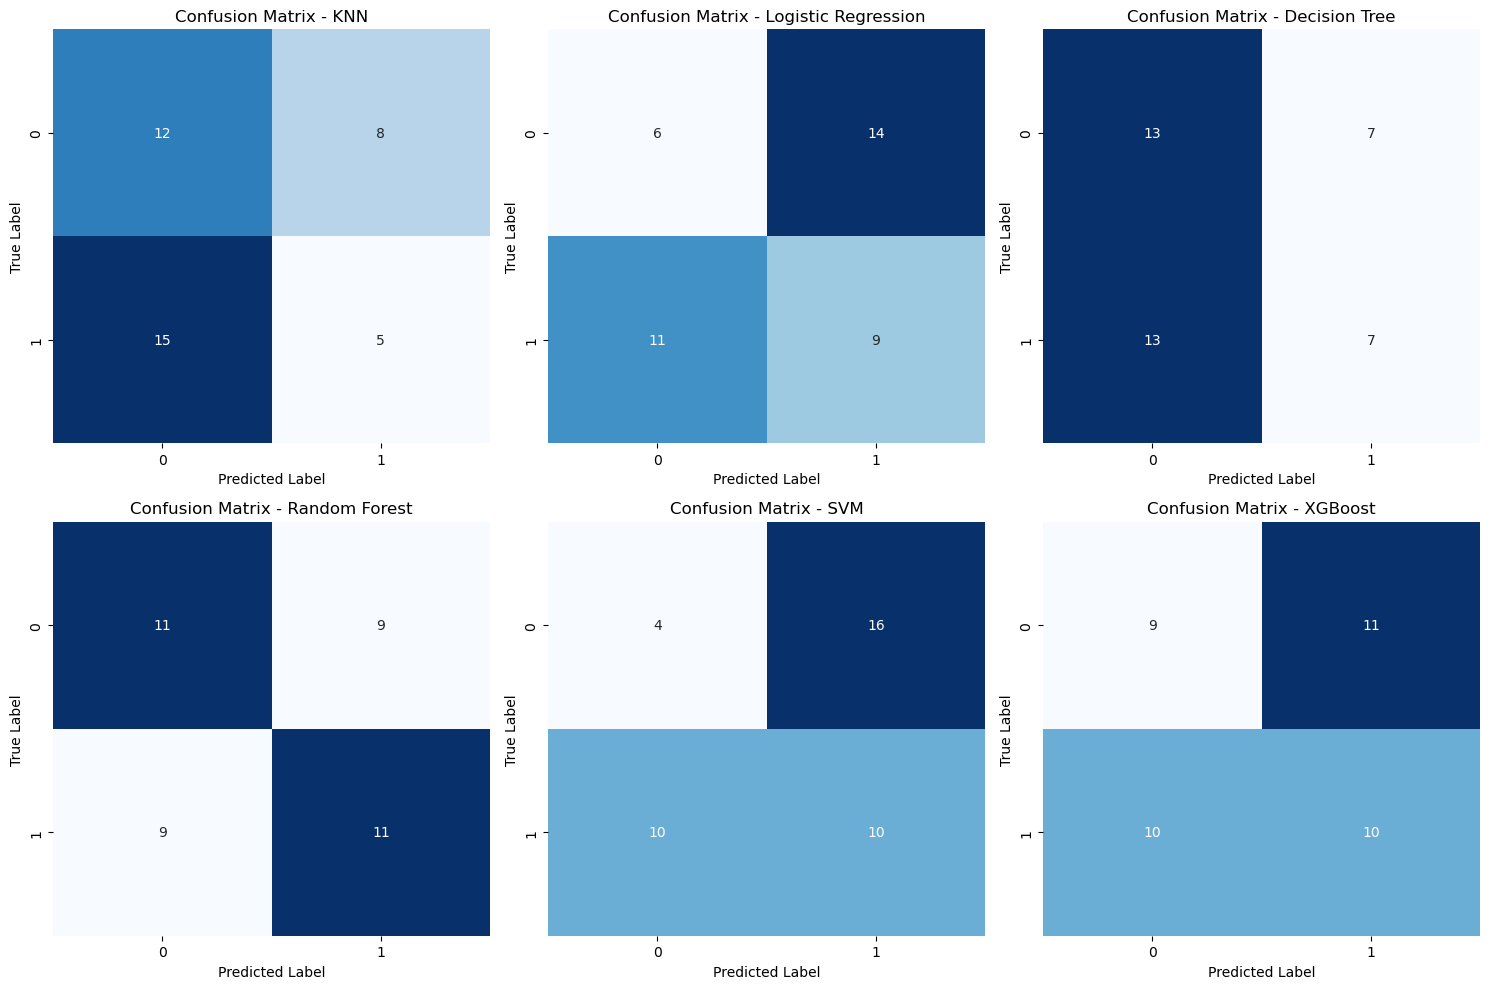

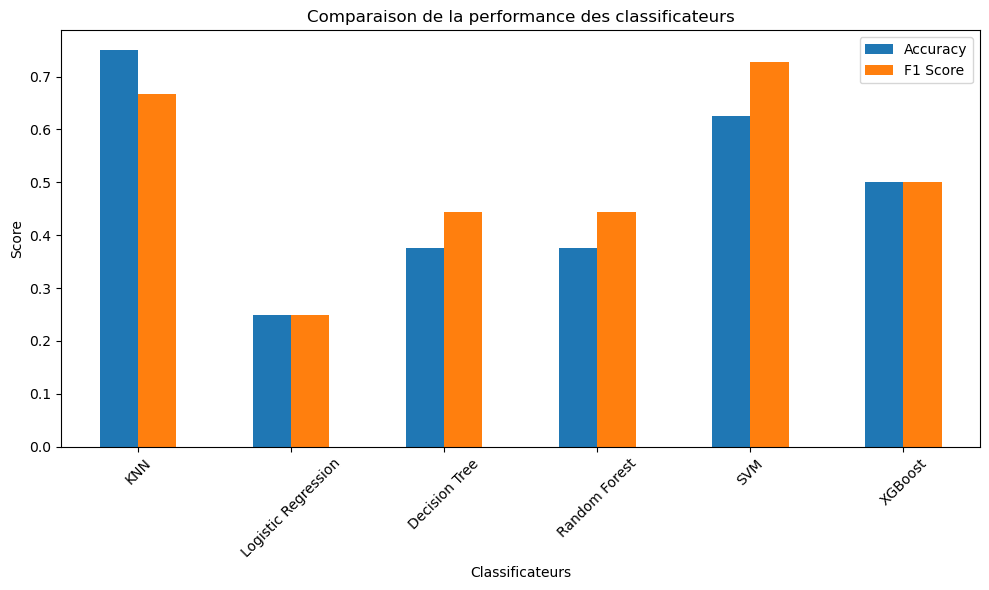

In [45]:
# Visualisations de la performance

# Matrices de confusion
num_classifiers = len(classifiers)
num_rows = int(np.ceil(num_classifiers / 3))
fig, axes = plt.subplots(num_rows, 3, figsize=(15, num_rows * 5))

for i, (clf_name, conf_matrix) in enumerate(confusion_matrices):
    row = i // 3
    col = i % 3
    ax = axes[row, col]
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(f'Confusion Matrix - {clf_name}')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.tight_layout()
os.makedirs('./figures/matrices_confusions', exist_ok=True)
plt.savefig('./figures/matrices_confusions/Modele3.png')

# Accuracy et F1 score
results_cv = pd.DataFrame(results_cv).T

# Plot accuracy and F1 score for each model
results_task1.plot(kind='bar', figsize=(10, 6))
plt.title('Comparaison de la performance des classificateurs')
plt.xlabel('Classificateurs')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend(loc='upper right')
plt.tight_layout()

os.makedirs('./figures/performance', exist_ok=True)
plt.savefig('./figures/performance/Modele3.png')

## Résumé des performances

| Classificateurs | Accuracy M1 | F1 M1 | Accuracy M2 | F1 M2 | Accuracy M3 | F1 M3 |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| KNN | 0.750 | 0.667 | 0.750 | 0.667 | 0.425 | 0.303 |
| Logistic Regression | 0.250 | 0.250 | 0.250 | 0.250 | 0.375 | 0.419 |
| Decision Tree | 0.375 | 0.444 | 0.375 | 0.444 | 0.500 | 0.444 |
| Random Forest | 0.625 | 0.667 | 0.625 | 0.444 | 0.450 | 0.476 |
| SVM | 0.625 | 0.727 | 0.625 | 0.727 | 0.350 | 0.435 |
| XGBoost | 0.500 | 0.500 | 0.375 | 0.444 | 0.475 | 0.488 |


*M1 : Réplication projet original — M2 : Sans redondance des features — 
M3 : Sans redondance des features avec validation croisée*